<a href="https://colab.research.google.com/github/sara-sgit/Plant-Disease-Classification/blob/main/Resnet_152.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing required Keras modules for building the model
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, Flatten , BatchNormalization
from keras.layers.convolutional import Conv2D,AveragePooling2D, MaxPooling2D
from keras.utils.np_utils import to_categorical
from keras import callbacks  #early stopping
from keras.callbacks import ModelCheckpoint  # to the model with the best accuracy


import tensorflow as tf
import pickle as pk
import numpy as np

# Scikit-learn libraries for additional ML tools and evaluation
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from keras.models import Model
from sklearn.metrics import classification_report

# For mounting Google Drive in Colab to access files
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import tensorflow
tf.__version__    # Displays TensorFlow version (to verify environment)

'2.12.0'

In [ ]:
# Set GPU configurations to manage memory usage
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config = ConfigProto()
config.gpu_options.per_process_gpu_memory_fraction = 0.85 #you can try 0.95
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)
# Import layers and modules needed for building the ResNet-based model
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet_v2 import ResNet152V2, preprocess_input
# Image preprocessing utilities
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.models import Sequential
import numpy as np
from glob import glob
#import matplotlib.pyplot as plt

 Setting Image Size and Defining Paths



In [ ]:
# Define the target image size (ResNet expects 224x224)
# re-size all the images to this
IMAGE_SIZE = [224, 224]


train_path = '/content/drive/MyDrive/data2/train'
valid_path = '/content/drive/MyDrive/data2/test'


In [ ]:

# Create the base model using ResNet152V2, pre-trained on ImageNet
# We remove the top fully connected layer (include_top=False) to customize it for our task


base_model = ResNet152V2(input_shape=IMAGE_SIZE  + [3], weights='imagenet', include_top=False)



# Freeze all layers in the base model so they won't be updated during training
for layer in base_model.layers:
    layer.trainable = False

234545216/234545216 [==============================] - 1s 0us/step


**texte en gras**

In [ ]:
# Get the list of folders (each folder typically represents a class)
folders = glob(train_path+'/*')
# Add custom layers on top of the pre-trained base:
x = Flatten()(base_model.output)
x = Dense(4096, activation='sigmoid', name ='fc1')(x)
x = Dense(10, activation='softmax', name='predictions')(x)

In [ ]:
# Combine the base model and the new custom layers to create the full model
model = Model(inputs=base_model.input, outputs=x)

In [ ]:
# Print a detailed summary of the model architecture
model.summary()

In [ ]:

# Define the loss function, optimizer, and metrics to use during training
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [ ]:
folders
# This displays the list of class folders that were loaded earlier.
# Useful for confirming the number of classes in your dataset.

['/content/drive/MyDrive/train/Tomato__Target_Spot',
 '/content/drive/MyDrive/train/Tomato_Spider_mites_Two_spotted_spider_mite',
 '/content/drive/MyDrive/train/Tomato_Septoria_leaf_spot',
 '/content/drive/MyDrive/train/Tomato__Tomato_YellowLeaf__Curl_Virus',
 '/content/drive/MyDrive/train/Tomato_Leaf_Mold',
 '/content/drive/MyDrive/train/Tomato_healthy',
 '/content/drive/MyDrive/train/Tomato_Early_blight',
 '/content/drive/MyDrive/train/Tomato_Late_blight',
 '/content/drive/MyDrive/train/Tomato_Bacterial_spot',
 '/content/drive/MyDrive/train/Tomato__Tomato_mosaic_virus']

 Preparing Image Data **Generators**

In [ ]:
# Import the ImageDataGenerator class for loading and augmenting image data
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0,
                                   zoom_range = 0,
                                   horizontal_flip = False)

test_datagen = ImageDataGenerator(rescale = 1./255)
# Set up the training data loader
training_set = train_datagen.flow_from_directory(train_path,
                                                 target_size = [224,224],
                                                 batch_size = 16,
                                                 class_mode = 'categorical')
# Set up the validation data loader

test_set = test_datagen.flow_from_directory(valid_path,
                                            target_size = [200,200],
                                            batch_size = 16,
                                            shuffle=False,
                                            class_mode = 'categorical')

Found 12811 images belonging to 10 classes.
Found 3200 images belonging to 10 classes.


In [ ]:
EPOCH=100  # Number of epochs to train
# Define where to save the best model file
path='/content/drive/MyDrive/resnet-models/Resnet152'+str(EPOCH)+'e.h5'
# Set up EarlyStopping to monitor validation accuracy and stop if no improvement for 50 epochs
es = callbacks.EarlyStopping(monitor='val_accuracy', mode='max', patience=50,restore_best_weights = True)
# Set up ModelCheckpoint to save the best model based on validation accuracy
mc = ModelCheckpoint(path, monitor='val_accuracy', mode='max', save_best_only=True,verbose= True)

In [ ]:
# Fit (train) the model on the training set and validate on the test set
# This will take significant time to run depending on dataset size and hardware

r = model.fit(
 training_set,
 validation_data=test_set,
 epochs=EPOCH,
 callbacks=[es, mc],  # Apply EarlyStopping and save best model
 steps_per_epoch=len(training_set),# One step per batch in the training set
 validation_steps=len(test_set)# One step per batch in the validation set
)

  3/801 [..............................] - ETA: 3:17:53 - loss: 11.0304 - accuracy: 0.2083

In [ ]:
# Load a previously saved model from a specified path (for inference or further evaluation)
path='/content/drive/MyDrive/BENNANI_AKRIB/Models /Resnet/ Resnet152_leaky_50e.h5'
model=load_model(path)

In [ ]:
# Print the list of validation accuracy values recorded after each epoch
print(r.history['val_accuracy'])
# Print the maximum (best) validation accuracy achieved during training
print(max(r.history['val_accuracy']))
# Find the epoch number (index) at which the best validation accuracy was achieved
I=r.history['val_accuracy'].index(max(r.history['val_accuracy']))


In [ ]:
# Use the trained model to predict probabilities for each class on the test set
y_predrob = model.predict(test_set)
# Import the necessary metrics functions from scikit-learn

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
# Convert the predicted probabilities into class labels by taking the index of the max probability for each sample
y_pred = np.argmax(y_predrob, axis=1)

#y_pred = np.argmax(y_pred, axis=1)
# (This commented line is redundant here since it's already handled above)
# y_pred = np.argmax(y_pred, axis=1)

# Print the confusion matrix to see how well the model performed for each class
print('Confusion Matrix')
print(confusion_matrix(test_set.classes, y_pred))

# Access the true labels from the test set
labels=test_set.labels
# Calculate the overall accuracy manually:
# Compare predicted labels with true labels, convert boolean to integers (1 for correct, 0 for incorrect),
# sum up the correct predictions, and divide by the total number of samples
sum((labels==y_pred)*1)/len(y_pred)


200/200 [==============================] - 23s 114ms/step
Confusion Matrix
[[418   0   1   0   4   0   1   1   0   0]
 [ 18 118  37   5  16   3   0   2   1   0]
 [  0   3 373   2   3   0   1   0   0   0]
 [  2   0   8 165   8   4   0   1   2   0]
 [  6   0  12   6 325   3   1   0   0   1]
 [  1   1   3   2   1 318   6   1   0   0]
 [  7   6  15   0   7  15 218   2   0  11]
 [  4   0   2   0   1   3   0 632   0   0]
 [  0   0   0   1   2   0   0   0  72   0]
 [  0   0   0   0   0   2   6   0   1 309]]


0.92125

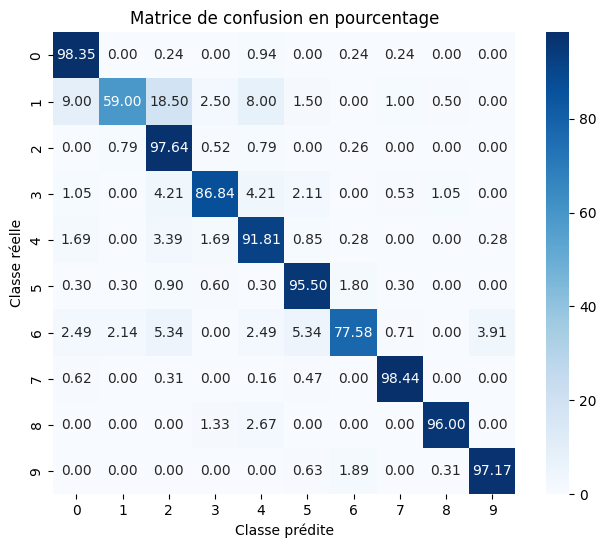

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix using true labels and predicted labels
conf_matrix = confusion_matrix(labels, y_pred)

# Convert counts to percentages for easier interpretation:
# Divide each row by the sum of that row (to get class-wise percentages)
conf_matrix_percentage = conf_matrix / np.sum(conf_matrix, axis=1, keepdims=True) * 100

# Create a list of class labels (converted to strings) for axis labels
labels = np.unique(labels)
labels = [str(label) for label in labels]

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_percentage, annot=True, fmt='.2f', cmap='Blues', cbar=True, square=True,
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Classe prédite')
plt.ylabel('Classe réelle')
plt.title('Matrice de confusion en pourcentage')
plt.show()

In [ ]:
# Save the predicted probability vectors to a file using pickle
pk.dump(y_predrob,open('/content/drive/MyDrive/Vars/pred_vectors/RESNET/RESNET-proba-', 'wb'))
pk.dump(y_pred,open('/content/drive/MyDrive/Vars/pred_vectors/RESNET/RESNET_y_pred_', 'wb'))

In [ ]:
# Create a training data generator that reads images from the specified directory
training_set_1 = train_datagen.flow_from_directory(train_path,
                                                 target_size = (224, 224),
                                                 batch_size = 16, shuffle=False,
                                                 class_mode = 'categorical')

In [ ]:
# Extract the output of an intermediate layer ('fc1') from the model

# Get the output tensor of the layer named 'fc1'
output2 = model.get_layer('fc1').output
# Create a new model that takes the same input as the original model
# but outputs the result of the 'fc1' layer instead of the final output

new_model = tf.keras.models.Model(inputs=model.input, outputs=output2)
# Use the new model to generate the intermediate feature vectors (activations) for the training set
O2 = new_model.predict(training_set_1)

In [ ]:
# Print the extracted feature vectors (activations) from the 'fc1' layer
print(O2)


In [ ]:
# Save the extracted feature vectors (O2) to a pickle file for later use
pk.dump(O2,open('/content/drive/MyDrive/FEATURES/RESNET/F_TRAIN_RESNET.pickle', 'wb'))

In [ ]:
print(O2[3100,1000:1500])

In [ ]:
# Extract the feature vectors (activations) from the 'fc1' layer for the test set

# Get the output tensor of the 'fc1' layer again (same as before)
output3 = model.get_layer('fc1').output
# Create a new model that takes the same input as the original model
# and outputs the activations of the 'fc1' layer
new_model = tf.keras.models.Model(inputs=model.input, outputs=output3)
# Use the new model to predict the feature vectors for the test set
O3 = new_model.predict(test_set)

In [ ]:
print(O3)

In [ ]:
# Save the extracted feature vectors (O2) to a pickle file for later use
pk.dump(O3,open('/content/drive/MyDrive/FEATURES/RESNET/F_TEST_RESNET.pickle', 'wb'))
